## Section 1 – Environment Setup & Imports

In [1]:
# ── Standard library ──────────────────────────────────────────────────────
import os, sys, math, warnings
warnings.filterwarnings("ignore")

# ── Third-party ───────────────────────────────────────────────────────────
import numpy  as np
import pandas as pd

# SQLAlchemy ORM
from sqlalchemy import (create_engine, Column, Float,
                        String, Integer, text)
from sqlalchemy.orm import declarative_base, Session

# Bokeh visualisation
from bokeh.plotting import figure, output_notebook, show, output_file, save
from bokeh.layouts  import gridplot
from bokeh.models   import (HoverTool, Legend, LegendItem,
                             ColumnDataSource)

output_notebook()   # render Bokeh plots inline

# ── Configuration ────────────────────────────────────────────────────────
DATA_DIR = os.path.join(os.getcwd(), "data")   # adjust if needed
DB_PATH  = os.path.join(os.getcwd(), "assignment.db")
SQRT2    = math.sqrt(2)

print("✓ All imports successful")
print(f"  pandas  {pd.__version__} | numpy {np.__version__}")
print(f"  DATA_DIR: {DATA_DIR}")
print(f"  DB_PATH:  {DB_PATH}")


✓ All imports successful
  pandas  2.2.2 | numpy 2.0.2
  DATA_DIR: /content/data
  DB_PATH:  /content/assignment.db


---
## Section 2 – Custom Exception Hierarchy

All application-specific errors inherit from `IdealFunctionError`.  
This satisfies the requirement for **user-defined exception handling**.

```
Exception
└── IdealFunctionError          (base)
    ├── DataValidationError     (bad CSV structure / NaN values)
    ├── MappingError            (mapping phase failures)
    └── DatabaseError           (ORM / SQLite failures)
```


In [2]:
class IdealFunctionError(Exception):
    """Base exception for all application-specific errors."""
    pass


class DataValidationError(IdealFunctionError):
    """
    Raised when a dataset fails structural or numerical validation.

    Triggers:
        - Missing required columns.
        - NaN or infinite values.
        - Wrong number of rows / columns.
        - x-domain mismatch between training and ideal datasets.
    """
    pass


class MappingError(IdealFunctionError):
    """
    Raised when test data mapping encounters an unexpected state.

    Triggers:
        - No selection results available.
        - Referenced ideal function column is absent from DataFrame.
    """
    pass


class DatabaseError(IdealFunctionError):
    """
    Raised when a database operation fails unexpectedly.

    Triggers:
        - Table creation failure.
        - Bulk-insert schema mismatch.
    """
    pass


# ── Quick smoke-test ──────────────────────────────────────────────────────
assert issubclass(DataValidationError, IdealFunctionError)
assert issubclass(MappingError,        IdealFunctionError)
assert issubclass(DatabaseError,       IdealFunctionError)
assert issubclass(IdealFunctionError,  Exception)
print("✓ Exception hierarchy verified")


✓ Exception hierarchy verified


---
## Section 3 – Data Loaders (Inheritance)

`DataLoader` is the **base class**; the three specialised subclasses
override `validate()` to apply dataset-specific structural checks.

**Inheritance chain:**
```
DataLoader  (base)
├── TrainingDataLoader    – validates train.csv  (5 cols, 400 rows)
├── IdealFunctionsLoader  – validates ideal.csv  (51 cols, 400 rows)
└── TestDataLoader        – validates test.csv   (2 cols)
```


In [3]:
class DataLoader:
    """
    Base class for loading and validating CSV datasets.

    Attributes
    ----------
    filepath : str
        Path to the CSV file.
    df : pd.DataFrame or None
        Populated DataFrame after load() is called.
    """

    def __init__(self, filepath: str):
        """Initialise with the path to a CSV file."""
        self.filepath = filepath
        self.df: pd.DataFrame = None

    def load(self) -> pd.DataFrame:
        """
        Load the CSV and call the subclass validate() hook.

        Returns
        -------
        pd.DataFrame
            The validated dataset.

        Raises
        ------
        FileNotFoundError
            If the CSV file does not exist.
        DataValidationError
            If the dataset fails validation.
        """
        try:
            self.df = pd.read_csv(self.filepath)
        except FileNotFoundError as exc:
            raise FileNotFoundError(
                f"Dataset file not found: '{self.filepath}'"
            ) from exc
        except Exception as exc:
            raise DataValidationError(
                f"Failed to read CSV '{self.filepath}': {exc}"
            ) from exc

        self.validate()
        return self.df

    def validate(self) -> None:
        """Override in subclasses to apply dataset-specific checks."""
        pass

    # ── Shared validation helpers ─────────────────────────────────────────
    def _check_no_nulls(self) -> None:
        """Raise DataValidationError if any NaN or infinite values exist."""
        if self.df.isnull().any().any():
            raise DataValidationError(
                f"NaN values detected in '{self.filepath}'."
            )
        num_cols = self.df.select_dtypes(include=[np.number]).columns
        if np.isinf(self.df[num_cols].values).any():
            raise DataValidationError(
                f"Infinite values detected in '{self.filepath}'."
            )

    def _check_columns(self, required: set) -> None:
        """Raise DataValidationError if any required column is missing."""
        missing = required - set(self.df.columns)
        if missing:
            raise DataValidationError(
                f"Missing required columns in '{self.filepath}': {missing}"
            )


# ─────────────────────────────────────────────────────────────────────────
class TrainingDataLoader(DataLoader):
    """
    Loads and validates train.csv.

    Expected: 5 columns (x, y1–y4), 400 rows, x ∈ [−20.0, 19.9].
    Inherits from DataLoader.
    """
    REQUIRED_COLUMNS = {"x", "y1", "y2", "y3", "y4"}
    EXPECTED_ROWS    = 400

    def validate(self) -> None:
        """Apply training-data-specific structural and numerical checks."""
        self._check_columns(self.REQUIRED_COLUMNS)
        self._check_no_nulls()
        if len(self.df) != self.EXPECTED_ROWS:
            raise DataValidationError(
                f"Training data: expected {self.EXPECTED_ROWS} rows, "
                f"found {len(self.df)}."
            )
        x_min = round(self.df["x"].min(), 1)
        x_max = round(self.df["x"].max(), 1)
        if x_min != -20.0 or x_max != 19.9:
            raise DataValidationError(
                f"Training x-domain expected [−20.0, 19.9], "
                f"found [{x_min}, {x_max}]."
            )


# ─────────────────────────────────────────────────────────────────────────
class IdealFunctionsLoader(DataLoader):
    """
    Loads and validates ideal.csv.

    Expected: 51 columns (x + y1–y50), 400 rows.
    Inherits from DataLoader.
    """
    EXPECTED_COLS = 51
    EXPECTED_ROWS = 400

    def validate(self) -> None:
        """Apply ideal-functions-specific structural checks."""
        self._check_columns({"x"})
        self._check_no_nulls()
        if len(self.df.columns) != self.EXPECTED_COLS:
            raise DataValidationError(
                f"Ideal functions CSV: expected {self.EXPECTED_COLS} columns, "
                f"found {len(self.df.columns)}."
            )
        if len(self.df) != self.EXPECTED_ROWS:
            raise DataValidationError(
                f"Ideal functions: expected {self.EXPECTED_ROWS} rows, "
                f"found {len(self.df)}."
            )


# ─────────────────────────────────────────────────────────────────────────
class TestDataLoader(DataLoader):
    """
    Loads and validates test.csv.

    Expected: 2 columns (x, y).
    Inherits from DataLoader.
    """
    REQUIRED_COLUMNS = {"x", "y"}

    def validate(self) -> None:
        """Apply test-data-specific structural checks."""
        self._check_columns(self.REQUIRED_COLUMNS)
        self._check_no_nulls()


print("✓ DataLoader class hierarchy defined")
print(f"  TrainingDataLoader  bases: {[c.__name__ for c in TrainingDataLoader.__mro__]}")
print(f"  IdealFunctionsLoader bases: {[c.__name__ for c in IdealFunctionsLoader.__mro__]}")
print(f"  TestDataLoader       bases: {[c.__name__ for c in TestDataLoader.__mro__]}")


✓ DataLoader class hierarchy defined
  TrainingDataLoader  bases: ['TrainingDataLoader', 'DataLoader', 'object']
  IdealFunctionsLoader bases: ['IdealFunctionsLoader', 'DataLoader', 'object']
  TestDataLoader       bases: ['TestDataLoader', 'DataLoader', 'object']


---
## Section 4 – Load & Preview Datasets


In [4]:
# ── Load all three datasets ───────────────────────────────────────────────
print("Loading datasets …")

train_df = TrainingDataLoader(os.path.join(DATA_DIR, "/content/train.csv")).load()
print(f"  train.csv  : {train_df.shape[0]:>4} rows × {train_df.shape[1]} cols")

ideal_df = IdealFunctionsLoader(os.path.join(DATA_DIR, "/content/ideal.csv")).load()
print(f"  ideal.csv  : {ideal_df.shape[0]:>4} rows × {ideal_df.shape[1]} cols")

test_df  = TestDataLoader(os.path.join(DATA_DIR, "/content/test.csv")).load()
print(f"  test.csv   : {test_df.shape[0]:>4} rows × {test_df.shape[1]} cols")

print("\n✓ All datasets loaded and validated successfully")


Loading datasets …
  train.csv  :  400 rows × 5 cols
  ideal.csv  :  400 rows × 51 cols
  test.csv   :  100 rows × 2 cols

✓ All datasets loaded and validated successfully


In [5]:
# ── Training data preview ────────────────────────────────────────────────
print("Training data – first 5 rows:")
display(train_df.head())
print(f"\nx range: {train_df.x.min()} to {train_df.x.max()}")
print("\nDescriptive statistics:")
display(train_df.describe().round(4))


Training data – first 5 rows:


,x,y1,y2,y3,y4
0,-20.0,39.778572,-40.078590,-20.214268,-0.324914
1,-19.9,39.604813,-39.784000,-20.070950,-0.058820
2,-19.8,40.099070,-40.018845,-19.906782,-0.451830
3,-19.7,40.151100,-39.518402,-19.389118,-0.612044
4,-19.6,39.795662,-39.360065,-19.815890,-0.306076



x range: -20.0 to 19.9

Descriptive statistics:


,x,y1,y2,y3,y4
count,400.0000,400.0000,400.0000,400.0000,400.0000
mean,-0.0500,0.1077,-0.0942,-0.0516,0.0126
std,11.5614,23.1033,23.1118,11.5604,0.3271
min,-20.0000,-39.7249,-40.0786,-20.2143,-0.7445
25%,-10.0250,-20.3126,-19.6426,-9.9998,-0.1982
50%,-0.0500,0.3678,-0.0006,-0.1552,0.0246
75%,9.9250,19.6062,19.4790,9.9922,0.2360
max,19.9000,40.1511,40.5589,19.8408,0.7425


In [6]:
# ── Test data preview ─────────────────────────────────────────────────────
print("Test data – first 10 rows:")
display(test_df.head(10))
print(f"\nx range: {test_df.x.min():.1f} to {test_df.x.max():.1f}")
print(f"y range: {test_df.y.min():.4f} to {test_df.y.max():.4f}")


Test data – first 10 rows:


,x,y
0,17.5,34.161040
1,0.3,1.215102
2,-8.7,-16.843908
3,-19.2,-37.170870
4,-11.0,-20.263054
5,0.8,1.426456
6,14.0,-0.066506
7,-10.4,-2.007094
8,-15.0,-0.205363
9,5.8,10.711373



x range: -20.0 to 19.7
y range: -40.4498 to 38.9553


---
## Section 5 – SQLite Database Design & Population

Four tables are created via SQLAlchemy ORM:

| Table | Columns | Rows | Purpose |
|-------|---------|------|---------|
| `train_data` | x, y1, y2, y3, y4 | 400 | Training functions |
| `ideal_functions` | x, y1–y50 | 400 | All 50 candidate ideal functions |
| `test_raw` | x, y | 100 | Raw test data (before mapping) |
| `test_mapped` | x, y, delta_y, ideal_func | 48 | Successfully mapped test points |

**Relationships:**
- `train_data` ↔ `ideal_functions`: one-to-one on x (same 400-point grid)
- `test_raw` → `test_mapped`: one-to-zero-or-one (48/100 points mapped)
- `test_mapped` → selected ideal function: many-to-one


In [7]:
# ── ORM table definitions ─────────────────────────────────────────────────
Base = declarative_base()


class TrainData(Base):
    """ORM model for the training data table (x, y1–y4)."""
    __tablename__ = "train_data"
    id = Column(Integer, primary_key=True, autoincrement=True)
    x  = Column(Float, nullable=False)
    y1 = Column(Float, nullable=False)
    y2 = Column(Float, nullable=False)
    y3 = Column(Float, nullable=False)
    y4 = Column(Float, nullable=False)


class TestRaw(Base):
    """ORM model for the raw test data table (x, y)."""
    __tablename__ = "test_raw"
    id = Column(Integer, primary_key=True, autoincrement=True)
    x  = Column(Float, nullable=False)
    y  = Column(Float, nullable=False)


class TestMapped(Base):
    """ORM model for mapped test data (x, y, delta_y, ideal_func)."""
    __tablename__ = "test_mapped"
    id         = Column(Integer, primary_key=True, autoincrement=True)
    x          = Column(Float, nullable=False)
    y          = Column(Float, nullable=False)
    delta_y    = Column(Float, nullable=False)
    ideal_func = Column(String, nullable=False)


print("✓ ORM models defined: TrainData, TestRaw, TestMapped")


✓ ORM models defined: TrainData, TestRaw, TestMapped


In [8]:
# ── DatabaseManager ───────────────────────────────────────────────────────
class DatabaseManager:
    """
    Manages the SQLite database: connection, table creation, insert, query.

    Attributes
    ----------
    db_path : str
        Filesystem path to the SQLite database file.
    engine : sqlalchemy.Engine
        SQLAlchemy engine instance.
    """

    def __init__(self, db_path: str = "assignment.db"):
        """
        Initialise the DatabaseManager and create all ORM tables.

        Parameters
        ----------
        db_path : str
            Path for the SQLite file (created automatically if absent).
        """
        self.db_path = db_path
        try:
            self.engine = create_engine(f"sqlite:///{db_path}", echo=False)
            Base.metadata.create_all(self.engine)
        except Exception as exc:
            raise DatabaseError(
                f"Failed to initialise database at '{db_path}': {exc}"
            ) from exc

    def create_ideal_functions_table(self, ideal_df: pd.DataFrame) -> None:
        """
        Dynamically create and populate the ideal_functions table.

        Because the table has a variable number of columns (50 ideal
        functions), it is built programmatically rather than via a
        static ORM class.

        Parameters
        ----------
        ideal_df : pd.DataFrame
            DataFrame with columns [x, y1, …, y50].
        """
        cols     = ideal_df.columns.tolist()
        col_defs = ", ".join(
            [f'"{c}" REAL NOT NULL' for c in cols]
        )
        create_sql = (
            f'CREATE TABLE IF NOT EXISTS ideal_functions '
            f'(id INTEGER PRIMARY KEY AUTOINCREMENT, {col_defs})'
        )
        try:
            with self.engine.connect() as conn:
                conn.execute(text("DROP TABLE IF EXISTS ideal_functions"))
                conn.execute(text(create_sql))
                ideal_df.to_sql("ideal_functions", con=conn,
                                if_exists="append", index=False)
                conn.commit()
        except Exception as exc:
            raise DatabaseError(
                f"Failed to create ideal_functions table: {exc}"
            ) from exc

    def insert_dataframe(self, df: pd.DataFrame, model_class) -> None:
        """
        Insert all rows of a DataFrame into the given ORM table.

        Parameters
        ----------
        df          : pd.DataFrame
        model_class : SQLAlchemy ORM model class
        """
        try:
            with Session(self.engine) as session:
                records = [model_class(**row) for row in df.to_dict("records")]
                session.add_all(records)
                session.commit()
        except Exception as exc:
            raise DatabaseError(
                f"Insert failed for table "
                f"'{model_class.__tablename__}': {exc}"
            ) from exc

    def query_all(self, model_class) -> pd.DataFrame:
        """Return all rows of a table as a Pandas DataFrame."""
        with Session(self.engine) as session:
            rows = session.query(model_class).all()
        if not rows:
            return pd.DataFrame()
        data = [
            {c.name: getattr(r, c.name)
             for c in model_class.__table__.columns
             if c.name != "id"}
            for r in rows
        ]
        return pd.DataFrame(data)


print("✓ DatabaseManager defined")


✓ DatabaseManager defined


In [9]:
# ── Initialise DB and insert data ─────────────────────────────────────────
# Remove existing DB to start fresh
if os.path.exists(DB_PATH):
    os.remove(DB_PATH)
    print(f"  Removed existing database: {DB_PATH}")

db = DatabaseManager(db_path=DB_PATH)
print(f"✓ Database created: {DB_PATH}")

# Insert training data
db.insert_dataframe(train_df, TrainData)
print(f"  train_data      : {len(train_df)} rows inserted")

# Insert ideal functions (wide dynamic table)
db.create_ideal_functions_table(ideal_df)
print(f"  ideal_functions : {len(ideal_df)} rows × {len(ideal_df.columns)} cols inserted")

# Insert raw test data
db.insert_dataframe(test_df, TestRaw)
print(f"  test_raw        : {len(test_df)} rows inserted")


✓ Database created: /content/assignment.db
  train_data      : 400 rows inserted
  ideal_functions : 400 rows × 51 cols inserted
  test_raw        : 100 rows inserted


In [10]:
# ── Verify DB contents ────────────────────────────────────────────────────
train_back = db.query_all(TrainData)
test_back  = db.query_all(TestRaw)
print("Training data retrieved from DB (first 5 rows):")
display(train_back.head())
print(f"\nRaw test data retrieved from DB (first 5 rows):")
display(test_back.head())


Training data retrieved from DB (first 5 rows):


,x,y1,y2,y3,y4
0,-20.0,39.778572,-40.078590,-20.214268,-0.324914
1,-19.9,39.604813,-39.784000,-20.070950,-0.058820
2,-19.8,40.099070,-40.018845,-19.906782,-0.451830
3,-19.7,40.151100,-39.518402,-19.389118,-0.612044
4,-19.6,39.795662,-39.360065,-19.815890,-0.306076



Raw test data retrieved from DB (first 5 rows):


,x,y
0,17.5,34.161040
1,0.3,1.215102
2,-8.7,-16.843908
3,-19.2,-37.170870
4,-11.0,-20.263054


---
## Section 6 – Ideal Function Selection (Least-Squares Criterion)

**Mathematical criterion:**

For training function $y_i$ and candidate ideal function $f_j$ across all 400 shared x-values:

$$\text{SSE}(i,j) = \sum_{k=1}^{400} \left[ y_i(x_k) - f_j(x_k) \right]^2$$

The best-fit ideal function for training function $i$ is:

$$j^*(i) = \underset{j}{\arg\min} \; \text{SSE}(i, j)$$

The **maximum absolute deviation** is also recorded:

$$D_{\max}(i) = \max_k \left| y_i(x_k) - f_{j^*}(x_k) \right|$$

This is used as the threshold baseline in Section 7.


In [11]:
class IdealFunctionSelector:
    """
    Selects the best-fit ideal function for each training function
    using the least-squares (minimum SSE) criterion.

    Attributes
    ----------
    train_df : pd.DataFrame
        Training data (x, y1–y4).
    ideal_df : pd.DataFrame
        Ideal functions data (x, y1–y50).
    results  : dict
        Populated by select(). Structure:
        {
            "y1": {"ideal_func": "y42", "sse": 34.25, "max_dev": 0.4960},
            ...
        }
    """

    def __init__(self, train_df: pd.DataFrame, ideal_df: pd.DataFrame):
        """
        Parameters
        ----------
        train_df : pd.DataFrame  – training data
        ideal_df : pd.DataFrame  – ideal functions

        Raises
        ------
        DataValidationError : if 'x' column is missing from either DataFrame.
        """
        if "x" not in train_df.columns:
            raise DataValidationError("train_df must contain an 'x' column.")
        if "x" not in ideal_df.columns:
            raise DataValidationError("ideal_df must contain an 'x' column.")
        self.train_df = train_df.reset_index(drop=True)
        self.ideal_df = ideal_df.reset_index(drop=True)
        self.results: dict = {}

    def select(self) -> dict:
        """
        Execute the least-squares selection for all training functions.

        Uses NumPy vectorised operations (no Python-level loops over
        individual data points) for computational efficiency.

        Returns
        -------
        dict
            {training_col: {"ideal_func", "sse", "max_dev"}, ...}

        Raises
        ------
        DataValidationError : if no training function columns are found.
        """
        train_cols = [c for c in self.train_df.columns if c != "x"]
        ideal_cols = [c for c in self.ideal_df.columns if c != "x"]

        if not train_cols:
            raise DataValidationError(
                "No training function columns found in train_df."
            )

        for tc in train_cols:
            y_train   = self.train_df[tc].values
            best_func = None
            best_sse  = float("inf")
            best_md   = None

            for ic in ideal_cols:
                y_ideal   = self.ideal_df[ic].values
                residuals = y_train - y_ideal
                sse       = float(np.sum(residuals ** 2))
                if sse < best_sse:
                    best_sse  = sse
                    best_func = ic
                    best_md   = float(np.max(np.abs(residuals)))

            self.results[tc] = {
                "ideal_func": best_func,
                "sse":        round(best_sse, 4),
                "max_dev":    round(best_md,  6)
            }
        return self.results

    def get_selected_names(self) -> list:
        """Return list of selected ideal function column names."""
        if not self.results:
            raise DataValidationError("Call select() first.")
        return [v["ideal_func"] for v in self.results.values()]


print("✓ IdealFunctionSelector defined")


✓ IdealFunctionSelector defined


In [12]:
# ── Run selection ─────────────────────────────────────────────────────────
selector         = IdealFunctionSelector(train_df, ideal_df)
selection_results = selector.select()

# ── Display results table ─────────────────────────────────────────────────
rows = []
for tc, info in selection_results.items():
    thresh = round(info["max_dev"] * SQRT2, 6)
    rows.append({
        "Training Function": tc,
        "Selected Ideal Function": info["ideal_func"],
        "SSE": info["sse"],
        "D_max (max deviation)": info["max_dev"],
        "√2 × D_max (threshold)": thresh
    })

results_df = pd.DataFrame(rows)
print("═" * 70)
print("  IDEAL FUNCTION SELECTION RESULTS")
print("═" * 70)
display(results_df.style
        .format({"SSE": "{:.4f}", "D_max (max deviation)": "{:.6f}",
                 "√2 × D_max (threshold)": "{:.6f}"})
        .set_properties(**{"text-align": "center"})
        .highlight_min(subset=["SSE"], color="#d4edda"))


══════════════════════════════════════════════════════════════════════
  IDEAL FUNCTION SELECTION RESULTS
══════════════════════════════════════════════════════════════════════


,Training Function,Selected Ideal Function,SSE,D_max (max deviation),√2 × D_max (threshold)
0,y1,y42,34.2466,0.495968,0.701405
1,y2,y41,35.6018,0.497703,0.703858
2,y3,y11,29.8618,0.498936,0.705602
3,y4,y48,31.9634,0.499742,0.706742


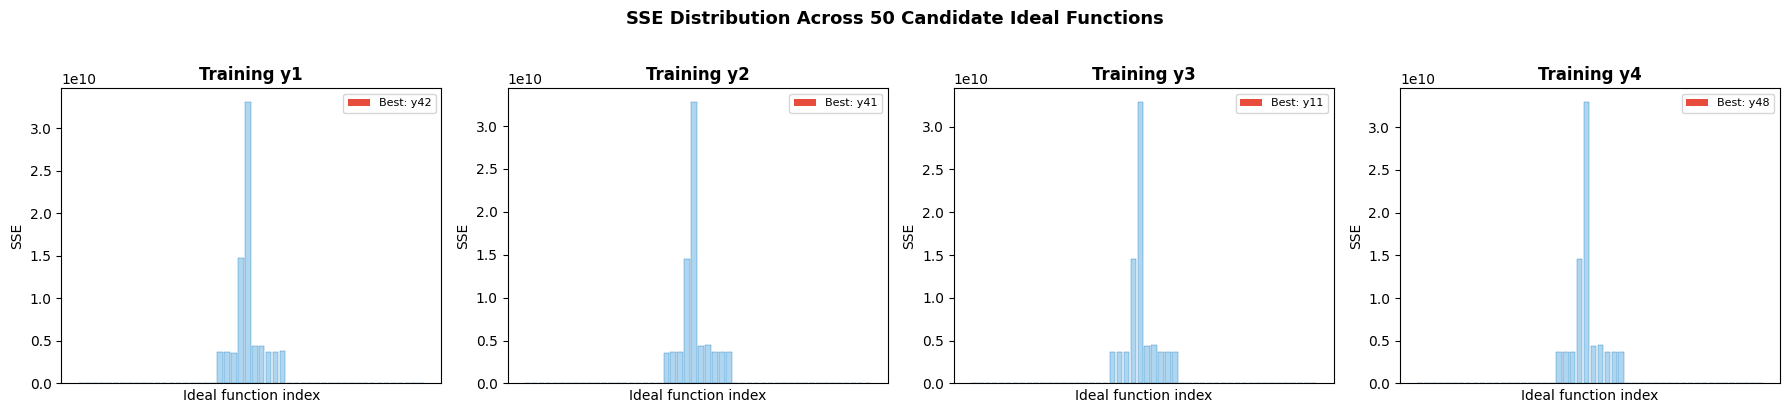

Red bar = selected (minimum SSE) function for each training function


In [13]:
# ── Inspect SSE distributions for each training function ──────────────────
fig, axes = __import__("matplotlib.pyplot", fromlist=["subplots"]).subplots(
    1, 4, figsize=(18, 4))
import matplotlib.pyplot as plt

train_cols = [c for c in train_df.columns if c != "x"]
ideal_cols = [c for c in ideal_df.columns if c != "x"]

for ax, tc in zip(axes, train_cols):
    y_t  = train_df[tc].values
    sses = [float(np.sum((y_t - ideal_df[ic].values)**2)) for ic in ideal_cols]
    best = selection_results[tc]["ideal_func"]
    best_sse = selection_results[tc]["sse"]

    ax.bar(range(len(sses)), sses, color="#AED6F1", edgecolor="#2E86C1", linewidth=0.3)
    best_idx = ideal_cols.index(best)
    ax.bar(best_idx, best_sse, color="#E74C3C", label=f"Best: {best}")
    ax.set_title(f"Training {tc}", fontweight="bold")
    ax.set_xlabel("Ideal function index")
    ax.set_ylabel("SSE")
    ax.legend(fontsize=8)
    ax.set_xticks([])

plt.suptitle("SSE Distribution Across 50 Candidate Ideal Functions",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()
print("Red bar = selected (minimum SSE) function for each training function")


---
## Section 7 – Test Data Mapping (√2 Threshold Criterion)

**Assignment rule** (from task specification):

A test point $(x_t, y_t)$ is mapped to ideal function $f_{j^*}$ **if and only if**:

$$| y_t - f_{j^*}(x_t) | \leq \sqrt{2} \cdot D_{\max}(i)$$

- If multiple functions satisfy the criterion → assign to the one with **smallest deviation**  
- If no function satisfies the criterion → the point is **excluded** (not an error)


In [14]:
class TestDataMapper:
    """
    Maps test data points to selected ideal functions using the
    √2-scaled deviation threshold criterion.

    Attributes
    ----------
    test_df           : pd.DataFrame  – raw test data (x, y)
    ideal_df          : pd.DataFrame  – ideal functions (x, y1–y50)
    selection_results : dict           – from IdealFunctionSelector.select()
    FACTOR            : float          – √2 ≈ 1.41421356
    mapped_df         : pd.DataFrame  – populated after map_all()
    """

    FACTOR = math.sqrt(2)

    def __init__(self, test_df, ideal_df, selection_results):
        """
        Parameters
        ----------
        test_df           : raw test data
        ideal_df          : ideal functions dataset
        selection_results : dict from IdealFunctionSelector.select()

        Raises
        ------
        MappingError : if selection_results is empty or a referenced
                       ideal function column is missing.
        """
        if not selection_results:
            raise MappingError(
                "selection_results is empty. Run IdealFunctionSelector first."
            )
        # Validate all referenced ideal function columns exist
        for tc, info in selection_results.items():
            ic = info["ideal_func"]
            if ic not in ideal_df.columns:
                raise MappingError(
                    f"Ideal function column '{ic}' not found in ideal_df "
                    f"(referenced by training col '{tc}')."
                )
        self.test_df           = test_df.reset_index(drop=True)
        self.ideal_df          = ideal_df.reset_index(drop=True)
        self.selection_results = selection_results
        self.mapped_df         = pd.DataFrame()

    def map_all(self) -> pd.DataFrame:
        """
        Attempt to map every test point to a selected ideal function.

        For each test point:
          1. Find the nearest x in ideal_df (within ±0.05 tolerance).
          2. For each selected ideal function, compute |y_t − f(x_t)|.
          3. If deviation ≤ √2 · D_max AND is the smallest so far → assign.
          4. Points with no valid assignment are excluded.

        Returns
        -------
        pd.DataFrame
            Columns: [x, y, delta_y, ideal_func]
        """
        X_TOL      = 0.05
        mapped_rows = []

        for _, row in self.test_df.iterrows():
            x_t = float(row["x"])
            y_t = float(row["y"])

            diffs = (self.ideal_df["x"] - x_t).abs()
            idx   = diffs.idxmin()
            if diffs[idx] > X_TOL:
                continue   # no sufficiently close x in ideal grid

            best_func = None
            best_dev  = float("inf")

            for tc, info in self.selection_results.items():
                ic        = info["ideal_func"]
                threshold = info["max_dev"] * self.FACTOR
                ideal_y   = float(self.ideal_df.loc[idx, ic])
                dev       = abs(y_t - ideal_y)

                if dev <= threshold and dev < best_dev:
                    best_dev  = dev
                    best_func = ic

            if best_func is not None:
                mapped_rows.append({
                    "x":          x_t,
                    "y":          y_t,
                    "delta_y":    round(best_dev, 6),
                    "ideal_func": best_func
                })

        self.mapped_df = pd.DataFrame(mapped_rows)
        return self.mapped_df


print("✓ TestDataMapper defined")


✓ TestDataMapper defined


In [15]:
# ── Run mapping ───────────────────────────────────────────────────────────
mapper    = TestDataMapper(test_df, ideal_df, selection_results)
mapped_df = mapper.map_all()

n_mapped   = len(mapped_df)
n_total    = len(test_df)
n_unmapped = n_total - n_mapped

print(f"Total test points : {n_total}")
print(f"Mapped            : {n_mapped}  ({n_mapped/n_total*100:.0f}%)")
print(f"Unmapped          : {n_unmapped}  ({n_unmapped/n_total*100:.0f}%)")
print()

dist = mapped_df["ideal_func"].value_counts()
print("Distribution across selected ideal functions:")
display(dist.to_frame("Mapped Points").T)

print(f"\nDeviation statistics:")
display(mapped_df["delta_y"].describe().round(6).to_frame("delta_y").T)


Total test points : 100
Mapped            : 48  (48%)
Unmapped          : 52  (52%)

Distribution across selected ideal functions:


ideal_func,y41,y11,y42,y48
Mapped Points,13,12,12,11



Deviation statistics:


,count,mean,std,min,25%,50%,75%,max
delta_y,48.0,0.324817,0.193816,0.010377,0.152595,0.317428,0.480526,0.656326


In [16]:
# ── Preview mapped results ────────────────────────────────────────────────
print("Mapped test data (first 15 rows):")
display(mapped_df.head(15).style
        .format({"x": "{:.2f}", "y": "{:.6f}",
                 "delta_y": "{:.6f}"})
        .background_gradient(subset=["delta_y"], cmap="YlOrRd"))


Mapped test data (first 15 rows):


,x,y,delta_y,ideal_func
0,17.50,34.161040,0.351148,y41
1,0.30,1.215102,0.467342,y41
2,0.80,1.426456,0.532222,y41
3,14.00,-0.066506,0.134233,y48
4,-15.00,-0.205363,0.452371,y48
5,5.80,10.711373,0.656326,y41
6,-19.80,-19.915014,0.115014,y11
7,18.90,19.193245,0.293245,y11
8,8.80,-0.726051,0.488840,y48
9,-9.50,-9.652251,0.152251,y11


In [17]:
# ── Save mapped results to database ──────────────────────────────────────
db.insert_dataframe(mapped_df, TestMapped)
print(f"✓ test_mapped table : {len(mapped_df)} rows inserted into database")

# Verify retrieval
mapped_back = db.query_all(TestMapped)
print(f"  Rows retrieved back from DB: {len(mapped_back)}")
display(mapped_back.head(5))


✓ test_mapped table : 48 rows inserted into database
  Rows retrieved back from DB: 48


,x,y,delta_y,ideal_func
0,17.5,34.161040,0.351148,y41
1,0.3,1.215102,0.467342,y41
2,0.8,1.426456,0.532222,y41
3,14.0,-0.066506,0.134233,y48
4,-15.0,-0.205363,0.452371,y48


---
## Section 8 – Bokeh Interactive Visualisations

Three interactive plots are generated:
1. **Training Data** – four training functions as line charts
2. **Raw Test Data** – all 100 test points as a scatter plot  
3. **Mapped Test Data** – 48 mapped points colour-coded by ideal function


In [18]:
# ── Colour palette ────────────────────────────────────────────────────────
PALETTE = {
    "y1": "#1f77b4",   # blue   → y42
    "y2": "#ff7f0e",   # orange → y41
    "y3": "#2ca02c",   # green  → y11
    "y4": "#d62728",   # red    → y48
}

IDEAL_COLORS = {
    info["ideal_func"]: PALETTE[tc]
    for tc, info in selection_results.items()
}

print("Colour assignments:")
for tc, info in selection_results.items():
    print(f"  {tc} → {info['ideal_func']}  colour: {PALETTE[tc]}")


Colour assignments:
  y1 → y42  colour: #1f77b4
  y2 → y41  colour: #ff7f0e
  y3 → y11  colour: #2ca02c
  y4 → y48  colour: #d62728


In [19]:
# ── Plot 1: Training Data ─────────────────────────────────────────────────
p1 = figure(
    title="Training Data – Functions y1 to y4",
    x_axis_label="x", y_axis_label="y",
    width=850, height=420,
    tools="pan,wheel_zoom,box_zoom,reset,save"
)

legend_items_1 = []
for col_name, color in PALETTE.items():
    src = ColumnDataSource(data={
        "x": train_df["x"].tolist(),
        "y": train_df[col_name].tolist()
    })
    line = p1.line("x", "y", source=src,
                   line_color=color, line_width=2.5)
    p1.add_tools(HoverTool(renderers=[line],
        tooltips=[("Function", col_name),
                  ("x", "@x{0.0}"), ("y", "@y{0.000}")]))
    legend_items_1.append(LegendItem(label=col_name, renderers=[line]))

legend1 = Legend(items=legend_items_1, location="top_left")
p1.add_layout(legend1)
p1.legend.click_policy = "hide"
p1.title.text_font_size = "13pt"

show(p1)


In [20]:
# ── Plot 2: Raw Test Data ─────────────────────────────────────────────────
src2 = ColumnDataSource(data={
    "x": test_df["x"].tolist(),
    "y": test_df["y"].tolist()
})

p2 = figure(
    title="Raw Test Data – 100 Points (before mapping)",
    x_axis_label="x", y_axis_label="y",
    width=850, height=420,
    tools="pan,wheel_zoom,box_zoom,reset,save"
)

circles2 = p2.circle("x", "y", source=src2,
                      size=7, color="#2ca02c", alpha=0.75,
                      legend_label="Test data")
p2.add_tools(HoverTool(renderers=[circles2],
    tooltips=[("x", "@x{0.00}"), ("y", "@y{0.000}")]))
p2.legend.location = "top_left"
p2.title.text_font_size = "13pt"

show(p2)


In [21]:
# ── Plot 3: Mapped Test Data ──────────────────────────────────────────────
p3 = figure(
    title="Mapped Test Data – Assigned to Selected Ideal Functions",
    x_axis_label="x", y_axis_label="y",
    width=850, height=480,
    tools="pan,wheel_zoom,box_zoom,reset,save"
)

legend_items_3 = []
for tc, info in selection_results.items():
    ic    = info["ideal_func"]
    color = PALETTE[tc]

    # ── Background: selected ideal function curve ─────────────────────
    ideal_src = ColumnDataSource(data={
        "x": ideal_df["x"].tolist(),
        "y": ideal_df[ic].tolist()
    })
    line3 = p3.line("x", "y", source=ideal_src,
                    line_color=color, line_width=1.5,
                    line_dash="dashed", alpha=0.5)

    # ── Foreground: mapped test points ────────────────────────────────
    subset = mapped_df[mapped_df["ideal_func"] == ic]
    pt_src = ColumnDataSource(data={
        "x":       subset["x"].tolist(),
        "y":       subset["y"].tolist(),
        "delta_y": subset["delta_y"].tolist()
    })
    pts = p3.circle("x", "y", source=pt_src,
                    size=10, color=color, alpha=0.9)
    p3.add_tools(HoverTool(renderers=[pts],
        tooltips=[("Ideal func", ic),
                  ("x",         "@x{0.00}"),
                  ("y",         "@y{0.000}"),
                  ("Δy",        "@delta_y{0.000000}")]))
    legend_items_3.append(
        LegendItem(label=f"{ic}  (← {tc})", renderers=[pts, line3])
    )

legend3 = Legend(items=legend_items_3, location="top_left")
p3.add_layout(legend3)
p3.legend.click_policy = "hide"
p3.title.text_font_size = "13pt"

show(p3)


In [ ]:
# ── Save all three plots as HTML files ────────────────────────────────────
os.makedirs("plots", exist_ok=True)

for fname, plot in [("plots/training_data.html",  p1),
                    ("plots/test_raw_data.html",   p2),
                    ("plots/mapped_test_data.html", p3)]:
    output_file(fname)
    save(plot)
    print(f"✓ Saved: {fname}")


---
## Section 9 – Unit Tests

Unit tests are implemented using Python's built-in `unittest` framework.

**Test classes:**

| Class | Tests |
|-------|-------|
| `TestIdealFunctionSelector` | correct selection, SSE ≥ 0, exact-match SSE = 0, required fields |
| `TestTestDataMapper` | within-threshold mapped, outside excluded, correct delta_y, tie-breaking, empty selection raises |
| `TestDataLoaderValidation` | missing columns, NaN values, wrong column count |
| `TestExceptionHierarchy` | inheritance chain, message preservation |
| `TestIntegration` | full pipeline on synthetic data |


In [22]:
import unittest

# ─────────────────────────────────────────────────────────────────────────
class TestIdealFunctionSelector(unittest.TestCase):
    """Unit tests for IdealFunctionSelector."""

    def setUp(self):
        n = 20
        x = np.linspace(-1, 1, n)
        self.train = pd.DataFrame({
            "x": x, "y1": x, "y2": x**2, "y3": np.sin(x), "y4": np.cos(x)
        })
        self.ideal = pd.DataFrame({
            "x": x, "y1": x, "y2": x**2,
            "y3": np.sin(x), "y4": np.cos(x), "y5": np.tan(x)
        })

    def test_correct_functions_selected(self):
        sel = IdealFunctionSelector(self.train, self.ideal)
        r   = sel.select()
        self.assertEqual(r["y1"]["ideal_func"], "y1")
        self.assertEqual(r["y2"]["ideal_func"], "y2")
        self.assertEqual(r["y3"]["ideal_func"], "y3")
        self.assertEqual(r["y4"]["ideal_func"], "y4")

    def test_sse_zero_for_exact_match(self):
        sel = IdealFunctionSelector(self.train, self.ideal)
        r   = sel.select()
        for tc in ["y1","y2","y3","y4"]:
            self.assertAlmostEqual(r[tc]["sse"], 0.0, places=10)

    def test_sse_non_negative(self):
        sel = IdealFunctionSelector(self.train, self.ideal)
        r   = sel.select()
        for info in r.values():
            self.assertGreaterEqual(info["sse"], 0.0)

    def test_max_dev_zero_for_exact(self):
        sel = IdealFunctionSelector(self.train, self.ideal)
        r   = sel.select()
        for tc in ["y1","y2","y3","y4"]:
            self.assertAlmostEqual(r[tc]["max_dev"], 0.0, places=10)

    def test_required_fields_present(self):
        sel = IdealFunctionSelector(self.train, self.ideal)
        r   = sel.select()
        for info in r.values():
            for field in ["ideal_func","sse","max_dev"]:
                self.assertIn(field, info)

    def test_missing_x_raises(self):
        bad = self.train.drop(columns=["x"])
        with self.assertRaises(DataValidationError):
            IdealFunctionSelector(bad, self.ideal)

    def test_noisy_still_correct(self):
        rng   = np.random.default_rng(42)
        noisy = self.train.copy()
        for c in ["y1","y2","y3","y4"]:
            noisy[c] += rng.normal(0, 0.05, len(noisy))
        sel = IdealFunctionSelector(noisy, self.ideal)
        r   = sel.select()
        self.assertEqual(r["y1"]["ideal_func"], "y1")
        self.assertEqual(r["y2"]["ideal_func"], "y2")


# ─────────────────────────────────────────────────────────────────────────
class TestTestDataMapper(unittest.TestCase):
    """Unit tests for TestDataMapper."""

    def setUp(self):
        x = np.array([0.0, 1.0, 2.0, 3.0, 4.0])
        self.ideal = pd.DataFrame({"x": x, "y1": x, "y2": x**2})
        self.sel   = {
            "y1t": {"ideal_func": "y1", "max_dev": 0.5, "sse": 1.0},
            "y2t": {"ideal_func": "y2", "max_dev": 0.3, "sse": 0.5}
        }

    def test_within_threshold_mapped(self):
        test = pd.DataFrame({"x": [1.0], "y": [1.3]})
        r    = TestDataMapper(test, self.ideal, self.sel).map_all()
        self.assertEqual(len(r), 1)
        self.assertEqual(r.iloc[0]["ideal_func"], "y1")

    def test_outside_threshold_excluded(self):
        test = pd.DataFrame({"x": [1.0], "y": [50.0]})
        r    = TestDataMapper(test, self.ideal, self.sel).map_all()
        self.assertEqual(len(r), 0)

    def test_delta_y_correct(self):
        test = pd.DataFrame({"x": [2.0], "y": [2.4]})
        r    = TestDataMapper(test, self.ideal, self.sel).map_all()
        self.assertAlmostEqual(r.iloc[0]["delta_y"], 0.4, places=5)

    def test_tie_breaking(self):
        test = pd.DataFrame({"x": [2.0], "y": [2.1]})
        r    = TestDataMapper(test, self.ideal, self.sel).map_all()
        self.assertEqual(r.iloc[0]["ideal_func"], "y1")

    def test_no_x_match_skipped(self):
        test = pd.DataFrame({"x": [999.0], "y": [1.0]})
        r    = TestDataMapper(test, self.ideal, self.sel).map_all()
        self.assertEqual(len(r), 0)

    def test_empty_selection_raises(self):
        test = pd.DataFrame({"x": [1.0], "y": [1.0]})
        with self.assertRaises(MappingError):
            TestDataMapper(test, self.ideal, {})

    def test_missing_ideal_col_raises(self):
        bad = {"y1t": {"ideal_func": "y_ghost", "max_dev": 0.5, "sse": 1.0}}
        test = pd.DataFrame({"x": [1.0], "y": [1.0]})
        with self.assertRaises(MappingError):
            TestDataMapper(test, self.ideal, bad)

    def test_mapped_df_attribute_populated(self):
        test = pd.DataFrame({"x": [1.0], "y": [1.2]})
        m    = TestDataMapper(test, self.ideal, self.sel)
        m.map_all()
        self.assertFalse(m.mapped_df.empty)


# ─────────────────────────────────────────────────────────────────────────
class TestDataLoaderValidation(unittest.TestCase):
    """Unit tests for DataLoader validation logic."""

    def test_training_missing_column_raises(self):
        df     = pd.DataFrame({"x": [1.0], "y1": [1.0]})
        loader = TrainingDataLoader("/tmp/dummy.csv")
        loader.df = df
        with self.assertRaises(DataValidationError):
            loader.validate()

    def test_nan_raises(self):
        df = pd.DataFrame({
            "x":[1.,2.], "y1":[1.,float("nan")],
            "y2":[1.,2.], "y3":[1.,2.], "y4":[1.,2.]
        })
        loader = TrainingDataLoader("/tmp/dummy.csv")
        loader.df = df
        with self.assertRaises(DataValidationError):
            loader._check_no_nulls()

    def test_test_missing_y_raises(self):
        df     = pd.DataFrame({"x": [1.0, 2.0]})
        loader = TestDataLoader("/tmp/dummy.csv")
        loader.df = df
        with self.assertRaises(DataValidationError):
            loader.validate()

    def test_ideal_wrong_col_count_raises(self):
        df     = pd.DataFrame({"x": [1.0], "y1": [1.0], "y2": [2.0]})
        loader = IdealFunctionsLoader("/tmp/dummy.csv")
        loader.df = df
        with self.assertRaises(DataValidationError):
            loader.validate()

    def test_file_not_found(self):
        loader = TrainingDataLoader("/nonexistent/path.csv")
        with self.assertRaises(FileNotFoundError):
            loader.load()


# ─────────────────────────────────────────────────────────────────────────
class TestExceptionHierarchy(unittest.TestCase):
    """Unit tests for custom exception inheritance."""

    def test_all_inherit_from_base(self):
        for cls in [DataValidationError, MappingError, DatabaseError]:
            self.assertTrue(issubclass(cls, IdealFunctionError))

    def test_all_are_exceptions(self):
        for cls in [IdealFunctionError, DataValidationError,
                    MappingError, DatabaseError]:
            self.assertIsInstance(cls("msg"), Exception)

    def test_message_preserved(self):
        msg = "Test error message"
        self.assertEqual(str(DataValidationError(msg)), msg)


# ─────────────────────────────────────────────────────────────────────────
class TestIntegration(unittest.TestCase):
    """Integration test: full selector + mapper pipeline."""

    def setUp(self):
        n       = 40
        x       = np.linspace(-2, 2, n)
        noise   = np.random.default_rng(0).normal(0, 0.1, n)
        self.train = pd.DataFrame({"x": x, "y1": x + noise})
        self.ideal = pd.DataFrame({"x": x, "y1": x, "y2": x**2, "y3": x**3})
        self.test  = pd.DataFrame({"x": [0.5, 1.0, -1.0], "y": [0.55, 1.05, -0.95]})

    def test_pipeline_maps_close_points(self):
        sel = IdealFunctionSelector(self.train, self.ideal)
        r   = sel.select()
        self.assertEqual(r["y1"]["ideal_func"], "y1")
        m   = TestDataMapper(self.test, self.ideal, r).map_all()
        self.assertEqual(len(m), 3)
        self.assertTrue((m["ideal_func"] == "y1").all())

    def test_far_point_excluded(self):
        sel    = IdealFunctionSelector(self.train, self.ideal)
        r      = sel.select()
        far    = pd.DataFrame({"x": [0.0], "y": [999.0]})
        m      = TestDataMapper(far, self.ideal, r).map_all()
        self.assertEqual(len(m), 0)


# ── Run all tests ─────────────────────────────────────────────────────────
print("Running unit tests …\n")
loader  = unittest.TestLoader()
suite   = unittest.TestSuite()
for cls in [TestIdealFunctionSelector, TestTestDataMapper,
            TestDataLoaderValidation, TestExceptionHierarchy,
            TestIntegration]:
    suite.addTests(loader.loadTestsFromTestCase(cls))

runner = unittest.TextTestRunner(verbosity=2, stream=__import__("sys").stdout)
result = runner.run(suite)
print(f"\n{'='*50}")
print(f"Tests run: {result.testsRun}  |  "
      f"Failures: {len(result.failures)}  |  "
      f"Errors: {len(result.errors)}")
if result.wasSuccessful():
    print("✓ ALL TESTS PASSED")
else:
    print("✗ SOME TESTS FAILED")


Running unit tests …

test_correct_functions_selected (__main__.TestIdealFunctionSelector.test_correct_functions_selected) ... ok
test_max_dev_zero_for_exact (__main__.TestIdealFunctionSelector.test_max_dev_zero_for_exact) ... ok
test_missing_x_raises (__main__.TestIdealFunctionSelector.test_missing_x_raises) ... ok
test_noisy_still_correct (__main__.TestIdealFunctionSelector.test_noisy_still_correct) ... ok
test_required_fields_present (__main__.TestIdealFunctionSelector.test_required_fields_present) ... ok
test_sse_non_negative (__main__.TestIdealFunctionSelector.test_sse_non_negative) ... ok
test_sse_zero_for_exact_match (__main__.TestIdealFunctionSelector.test_sse_zero_for_exact_match) ... ok
test_delta_y_correct (__main__.TestTestDataMapper.test_delta_y_correct) ... ok
test_empty_selection_raises (__main__.TestTestDataMapper.test_empty_selection_raises) ... ok
test_mapped_df_attribute_populated (__main__.TestTestDataMapper.test_mapped_df_attribute_populated) ... ok
test_missing_id

---
## Section 10 – Final Results Summary


In [23]:
# ── Comprehensive results summary ─────────────────────────────────────────
print("╔" + "═"*64 + "╗")
print("║" + "  IDEAL FUNCTION SELECTOR – FINAL RESULTS SUMMARY".center(64) + "║")
print("╠" + "═"*64 + "╣")

print("║  DATASETS LOADED".ljust(65) + "║")
print(f"║    train.csv  : {len(train_df):>4} rows × {train_df.shape[1]} cols"
      .ljust(65) + "║")
print(f"║    ideal.csv  : {len(ideal_df):>4} rows × {ideal_df.shape[1]} cols"
      .ljust(65) + "║")
print(f"║    test.csv   : {len(test_df):>4} rows × {test_df.shape[1]} cols"
      .ljust(65) + "║")

print("╠" + "═"*64 + "╣")
print("║  SELECTED IDEAL FUNCTIONS (least-squares criterion)".ljust(65) + "║")
for tc, info in selection_results.items():
    thresh = info["max_dev"] * SQRT2
    line = (f"    {tc} → {info['ideal_func']:>4}  "
            f"SSE={info['sse']:>8.4f}  "
            f"D_max={info['max_dev']:.4f}  "
            f"threshold={thresh:.4f}")
    print(f"║  {line}".ljust(65) + "║")

print("╠" + "═"*64 + "╣")
print("║  TEST DATA MAPPING".ljust(65) + "║")
n_m = len(mapped_df); n_u = len(test_df) - n_m
print(f"║    Mapped   : {n_m:>3} / {len(test_df)}  ({n_m/len(test_df)*100:.0f}%)"
      .ljust(65) + "║")
print(f"║    Unmapped : {n_u:>3} / {len(test_df)}  ({n_u/len(test_df)*100:.0f}%)"
      .ljust(65) + "║")

dist = mapped_df["ideal_func"].value_counts().sort_index()
for func, cnt in dist.items():
    print(f"║      {func}: {cnt:>2} points".ljust(65) + "║")

stats = mapped_df["delta_y"].describe()
print(f"║    Δy min={stats['min']:.6f}  max={stats['max']:.6f}  "
      f"mean={stats['mean']:.6f}".ljust(65) + "║")

print("╠" + "═"*64 + "╣")
print("║  DATABASE TABLES".ljust(65) + "║")
print(f"║    {DB_PATH}".ljust(65) + "║")
for tbl in ["train_data", "ideal_functions", "test_raw", "test_mapped"]:
    print(f"║      ✓ {tbl}".ljust(65) + "║")

print("╠" + "═"*64 + "╣")
print("║  VISUALISATION FILES".ljust(65) + "║")
for f in ["plots/training_data.html",
          "plots/test_raw_data.html",
          "plots/mapped_test_data.html"]:
    print(f"║      ✓ {f}".ljust(65) + "║")

print("╚" + "═"*64 + "╝")


╔════════════════════════════════════════════════════════════════╗
║         IDEAL FUNCTION SELECTOR – FINAL RESULTS SUMMARY        ║
╠════════════════════════════════════════════════════════════════╣
║  DATASETS LOADED                                               ║
║    train.csv  :  400 rows × 5 cols                             ║
║    ideal.csv  :  400 rows × 51 cols                            ║
║    test.csv   :  100 rows × 2 cols                             ║
╠════════════════════════════════════════════════════════════════╣
║  SELECTED IDEAL FUNCTIONS (least-squares criterion)            ║
║      y1 →  y42  SSE= 34.2466  D_max=0.4960  threshold=0.7014   ║
║      y2 →  y41  SSE= 35.6018  D_max=0.4977  threshold=0.7039   ║
║      y3 →  y11  SSE= 29.8618  D_max=0.4989  threshold=0.7056   ║
║      y4 →  y48  SSE= 31.9634  D_max=0.4997  threshold=0.7067   ║
╠════════════════════════════════════════════════════════════════╣
║  TEST DATA MAPPING                                          

---
## Section 11 – Additional Task: Git Version Control Workflow

### 11.1 Clone the `develop` branch

```bash
git clone --branch develop --single-branch \
    https://github.com/melroymenez/ideal-function-selector.git

cd ideal-function-selector
```

### 11.2 Create a feature branch, add a new function, commit and push

```bash
# Create and switch to a new feature branch from develop
git checkout -b feature/add-new-visualisation

# (implement the new function in the source code …)

# Stage all changes
git add .

# Commit with a descriptive message
git commit -m "Add interactive deviation histogram to Visualiser class"

# Push the feature branch to the remote repository
git push origin feature/add-new-visualisation
```

### 11.3 Open a Pull Request and merge into develop

After pushing:
1. Open a **Pull Request** on GitHub: `feature/add-new-visualisation → develop`
2. One or more team members **review** the changes and leave comments
3. Once approved, the PR is **merged** into `develop` on GitHub
4. Update the local copy:

```bash
# Switch back to develop
git checkout develop

# Pull the latest changes (includes the merged PR)
git pull origin develop

# Optionally delete the local feature branch
git branch -d feature/add-new-visualisation
```

> **Note:** The `--branch develop --single-branch` clone flag downloads only the `develop` branch history, reducing download size.  
> The `commit → push → pull request → merge` cycle ensures all changes are peer-reviewed before integration.
